# Fig. 10: Impact of Reverberation Time on Noise Reduction

This notebook reproduces the Fig. 10 simulation for the Spatial-Frequency GFANC pipeline. It uses the trained CRNN to predict the source grid location from the four-channel reference signal, selects the matching pretrained control filter, reconstructs the spatial-frequency control filter from the regression output, and plots the noise reduction versus reverberation time.

In [1]:
from pathlib import Path
import os
import sys
import warnings

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'CRNN.py').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

warnings.filterwarnings('ignore', category=UserWarning)

import numpy as np
import pandas as pd
import torch
import scipy.io as sio
import soundfile as sf
import matplotlib.pyplot as plt
import gpuRIR
from scipy.signal import firwin, lfilter, fftconvolve, resample

from CRNN import CRNN_Multi
from MyDataLoader_2D_BX import compute_stft_for_allchannels
from Fixed_filter_noise_cancellation_2x1x1 import Fixed_filter_controller_2x1x1_GFANC
from utilities_funcs import ambeo_vr_mic_positions, awgn, Construt_filter

print(f'Project root: {PROJECT_ROOT}')

Project root: /home/wangboxiang/ANC Projects/Spatial-Frequency-GFANC


## Helper Functions

`filter_decompose` is kept inside the notebook so the public release does not need to include the original `DFT_Filter_Decompose.py` file.

In [2]:
def filter_decompose(control_filter, num_subfilters, fs=16000):
    """Split one FIR control filter into frequency-band subfilters."""
    control_filter = np.asarray(control_filter, dtype=np.float64)
    n_taps = len(control_filter)
    spectrum = np.fft.fft(control_filter)
    sub_filters = np.zeros((num_subfilters, n_taps), dtype=np.float64)
    bins_per_band = n_taps // (num_subfilters * 2)

    for band_idx in range(num_subfilters):
        band_spectrum = np.zeros_like(spectrum)
        start = band_idx * bins_per_band + 1
        stop = (band_idx + 1) * bins_per_band + 1
        neg_start = -(band_idx + 1) * bins_per_band
        neg_stop = -start + 1

        if band_idx != num_subfilters - 1:
            band_spectrum[start:stop] = spectrum[start:stop]
            if neg_stop == 0:
                band_spectrum[neg_start:] = spectrum[neg_start:]
            else:
                band_spectrum[neg_start:neg_stop] = spectrum[neg_start:neg_stop]
        else:
            band_spectrum[start:neg_stop] = spectrum[start:neg_stop]

        sub_filters[band_idx, :] = np.fft.ifft(band_spectrum).real

    return sub_filters


def build_spatial_gfanc_filter(selected_cf, regression_output, num_subfilters=32):
    """Reconstruct a four-channel spatial-frequency GFANC filter from CRNN regression weights."""
    regression = regression_output.detach().cpu().numpy().reshape(-1)
    if regression.size < num_subfilters:
        regression = np.pad(regression, (0, num_subfilters - regression.size))
    else:
        regression = regression[:num_subfilters]

    reconstructed_channels = []
    for channel_filter in selected_cf:
        sub_filters = filter_decompose(channel_filter, num_subfilters=num_subfilters)
        reconstructed_channel, _ = Construt_filter(sub_filters, regression)
        reconstructed_channels.append(reconstructed_channel)

    return np.concatenate(reconstructed_channels, axis=0)


def make_bandpass_noise(low_hz, high_hz, length, fs, rms=0.3):
    """Generate RMS-normalized band-limited white noise."""
    bandpass = firwin(1024, [low_hz, high_hz], pass_zero=False, fs=fs)
    noise = lfilter(bandpass, [1.0], np.random.randn(length))
    return noise / np.sqrt(np.mean(noise**2)) * rms


def process_real_noise(file_path, target_fs, target_length, cutoff_hz, rms=0.3):
    """Load, resample, low-pass filter, and RMS-normalize one real-noise waveform."""
    data, sample_rate = sf.read(file_path)
    if data.ndim > 1:
        data = data[:, 0]
    if sample_rate != target_fs:
        data = resample(data, int(len(data) * target_fs / sample_rate))
    lowpass = firwin(1024, cutoff_hz, fs=target_fs, pass_zero=True)
    data = lfilter(lowpass, [1.0], data)
    data = data / np.sqrt(np.mean(data**2)) * rms
    if len(data) < target_length:
        data = np.tile(data, int(np.ceil(target_length / len(data))))
    return data[:target_length]


def decode_prediction(out_d, out_e, out_a):
    """Decode CRNN classification logits into the discrete source grid."""
    distance = DISTANCE_CANDIDATES[out_d.argmax(1).item()]
    elevation = ELEVATION_CANDIDATES[out_e.argmax(1).item()]
    azimuth = AZIMUTH_CANDIDATES[out_a.argmax(1).item()]
    return distance, elevation, azimuth

## Configuration and Assets

In [3]:
FS = 16000
FILTER_LENGTH = 1024
SEGMENT_LENGTH = int(0.5 * FS)
DURATION_SEC = 5
TARGET_LENGTH = int(DURATION_SEC * FS)
TARGET_RMS = 0.3
SNR_DB = 50
N_MC = 1
RANDOM_SEED = 0

MIC_CENTER = np.array([6, 4, 2.2])
ERROR_MIC = np.array([7, 4, 2.2])
ROOM_SIZE = [11, 9, 3.2]

TRUE_DISTANCE = 0.2
TRUE_ELEVATION = 30
TRUE_AZIMUTH = 120

theta = np.deg2rad(TRUE_AZIMUTH)
phi = np.deg2rad(TRUE_ELEVATION)
SOURCE_POSITION = MIC_CENTER + np.array([
    TRUE_DISTANCE * np.cos(phi) * np.cos(theta),
    TRUE_DISTANCE * np.cos(phi) * np.sin(theta),
    TRUE_DISTANCE * np.sin(phi),
])

DISTANCE_CANDIDATES = [0.2, 0.3, 0.4, 0.5]
ELEVATION_CANDIDATES = [-30, 30, 90]
AZIMUTH_CANDIDATES = [0, 60, 120, 180, 240, 300]
T60_VALUES = np.round(np.arange(0.1, 1.0, 0.1), 1)

MODEL_PATH = PROJECT_ROOT / 'CNN_models' / '2D_v1002_CRNN_merged_v5.pth'
SECONDARY_PATH_FILE = PROJECT_ROOT / 'SecondaryPath_final.mat'
NOISE_DIR = PROJECT_ROOT / 'finaltest_noises'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

required_files = [
    MODEL_PATH,
    SECONDARY_PATH_FILE,
    NOISE_DIR / '3-188726-A-35.wav',
    NOISE_DIR / 'compre.wav',
]
required_files.extend([
    PROJECT_ROOT / f'Pre_trained_CFs_T60_{t60:.1f}' / 'CF_0.2_30_120.mat'
    for t60 in T60_VALUES
])
missing_files = [str(path) for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError('Missing required Fig. 10 assets:\n' + '\n'.join(missing_files))

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SECONDARY_PATH = np.squeeze(sio.loadmat(SECONDARY_PATH_FILE)['Sec_path_cal'])

model = CRNN_Multi(
    in_channels=8,
    num_distance=4,
    num_elevation=3,
    num_azimuth=6,
    reg_dim=8,
    cnn_channels=[16, 32, 64],
    gru_hidden=128,
    gru_layers=2,
    bidirectional=False,
    fc_dim=96,
    dropout=0.2,
    freq_bins=513,
)
model.load_state_dict(torch.load(MODEL_PATH, map_location='cpu'))
model.eval().to(DEVICE)

noise_configs = {
    '100-700 Hz': {'type': 'synthetic', 'low': 100, 'high': 700},
    '50-450 Hz': {'type': 'synthetic', 'low': 50, 'high': 450},
    'Washing Machine': {'type': 'real'},
    'Compressor': {'type': 'real'},
}

real_noise_bases = {
    'Washing Machine': process_real_noise(NOISE_DIR / '3-188726-A-35.wav', FS, TARGET_LENGTH, cutoff_hz=2000),
    'Compressor': process_real_noise(NOISE_DIR / 'compre.wav', FS, TARGET_LENGTH, cutoff_hz=2000),
}

print(f'Device: {DEVICE}')
print(f'Model: {MODEL_PATH.relative_to(PROJECT_ROOT)}')
print(f'Noise cases: {list(noise_configs)}')

/tmp/ipykernel_1021899/3859622149.py:69: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location='cpu'))


Device: cuda
Model: CNN_models/2D_v1002_CRNN_merged_v5.pth
Noise cases: ['100-700 Hz', '50-450 Hz', 'Washing Machine', 'Compressor']


## Run the Fig. 10 Simulation

In [4]:
np.random.seed(RANDOM_SEED)

nr_mean = {name: [] for name in noise_configs}
nr_std = {name: [] for name in noise_configs}
prediction_log = []

for t60 in T60_VALUES:
    t60_tag = f'{t60:.1f}'
    cf_dir = PROJECT_ROOT / f'Pre_trained_CFs_T60_{t60_tag}'
    nominal_cf_path = cf_dir / f'CF_{TRUE_DISTANCE}_{TRUE_ELEVATION}_{TRUE_AZIMUTH}.mat'

    beta = gpuRIR.beta_SabineEstimation(ROOM_SIZE, float(t60))
    tmax = gpuRIR.att2t_SabineEstimator(60.0, float(t60))
    nb_img = gpuRIR.t2n(tmax, ROOM_SIZE)

    rirs_ref = gpuRIR.simulateRIR(
        ROOM_SIZE,
        beta,
        SOURCE_POSITION,
        ambeo_vr_mic_positions(MIC_CENTER),
        nb_img,
        tmax,
        FS,
        mic_pattern='card',
        orV_rcv=np.array([[1, 0, 0], [-1, 0, 0], [0, 1, 0], [0, -1, 0]]),
    )
    rirs_error = gpuRIR.simulateRIR(
        ROOM_SIZE,
        beta,
        SOURCE_POSITION,
        np.array([ERROR_MIC]),
        nb_img,
        tmax,
        FS,
    )

    for noise_name, config in noise_configs.items():
        nr_trials = []

        for mc_trial in range(N_MC):
            if config['type'] == 'synthetic':
                primary_noise = make_bandpass_noise(
                    config['low'], config['high'], TARGET_LENGTH, FS, TARGET_RMS
                )
            else:
                primary_noise = real_noise_bases[noise_name].copy()

            full_sig_test = np.zeros((4, len(primary_noise) + rirs_ref.shape[-1] - 1))
            for mic_idx in range(4):
                full_sig_test[mic_idx] = fftconvolve(primary_noise, rirs_ref[0, mic_idx, :], mode='full')
            full_sig_test = full_sig_test[:, :len(primary_noise)].T
            full_sig_test = awgn(full_sig_test, SNR_DB)

            disturbance = fftconvolve(primary_noise, rirs_error[0, 0, :], mode='full')[:len(primary_noise)]
            signal_tensor = torch.tensor(full_sig_test.T, dtype=torch.float32, device=DEVICE)
            num_segments = signal_tensor.size(1) // SEGMENT_LENGTH
            constructed_filters = []

            for segment_idx in range(num_segments):
                segment = signal_tensor[:, segment_idx * SEGMENT_LENGTH:(segment_idx + 1) * SEGMENT_LENGTH]
                spec = compute_stft_for_allchannels(segment.cpu())
                model_input = spec.unsqueeze(0).to(DEVICE)

                with torch.no_grad():
                    out_d, out_e, out_a, out_r = model(model_input)

                pred_distance, pred_elevation, pred_azimuth = decode_prediction(out_d, out_e, out_a)
                selected_cf_path = cf_dir / f'CF_{pred_distance}_{pred_elevation}_{pred_azimuth}.mat'
                if not selected_cf_path.exists():
                    selected_cf_path = nominal_cf_path

                selected_cf = sio.loadmat(selected_cf_path)['W']
                constructed_filters.append(build_spatial_gfanc_filter(selected_cf, out_r))
                prediction_log.append({
                    'T60_s': t60_tag,
                    'noise': noise_name,
                    'mc_trial': mc_trial + 1,
                    'segment': segment_idx + 1,
                    'distance_m': pred_distance,
                    'elevation_deg': pred_elevation,
                    'azimuth_deg': pred_azimuth,
                    'control_filter': selected_cf_path.relative_to(PROJECT_ROOT).as_posix(),
                })

            constructed_filters = np.stack(constructed_filters, axis=0)

            filtered_references = np.zeros((len(disturbance), 4))
            for channel_idx in range(4):
                filtered_references[:, channel_idx] = lfilter(SECONDARY_PATH, 1, full_sig_test[:, channel_idx])

            controller = Fixed_filter_controller_2x1x1_GFANC(
                frame_length=SEGMENT_LENGTH,
                control_filters=constructed_filters,
                num_channels=4,
                filter_length=FILTER_LENGTH,
            )
            error_signal = controller.noise_cancellation(disturbance, filtered_references).numpy()

            eval_samples = min(int(4.5 * FS), len(disturbance))
            rms_disturbance = np.sqrt(np.mean(disturbance[-eval_samples:] ** 2))
            rms_error = np.sqrt(np.mean(error_signal[-eval_samples:] ** 2))
            nr_trials.append(20 * np.log10(rms_disturbance / rms_error))

        nr_mean[noise_name].append(float(np.mean(nr_trials)))
        ddof = 1 if len(nr_trials) > 1 else 0
        nr_std[noise_name].append(float(np.std(nr_trials, ddof=ddof)))
        print(
            f'T60={t60_tag}s | {noise_name:<15} | '
            f'NR={nr_mean[noise_name][-1]:6.2f} dB +/- {nr_std[noise_name][-1]:.2f} dB'
        )

prediction_df = pd.DataFrame(prediction_log)
prediction_summary = (
    prediction_df
    .groupby(['T60_s', 'noise', 'distance_m', 'elevation_deg', 'azimuth_deg'], as_index=False)
    .size()
    .rename(columns={'size': 'segments'})
)
pd.set_option('display.max_rows', None)
prediction_summary

T60=0.1s | 100-700 Hz      | NR= 22.79 dB +/- 0.00 dB


T60=0.1s | 50-450 Hz       | NR= 20.97 dB +/- 0.00 dB


T60=0.1s | Washing Machine | NR= 18.75 dB +/- 0.00 dB


T60=0.1s | Compressor      | NR= 21.78 dB +/- 0.00 dB


T60=0.2s | 100-700 Hz      | NR= 22.22 dB +/- 0.00 dB


...

T60=0.9s | 100-700 Hz      | NR=  9.02 dB +/- 0.00 dB


T60=0.9s | 50-450 Hz       | NR=  9.42 dB +/- 0.00 dB


T60=0.9s | Washing Machine | NR= 11.94 dB +/- 0.00 dB


T60=0.9s | Compressor      | NR=  7.24 dB +/- 0.00 dB


,T60_s,noise,distance_m,elevation_deg,azimuth_deg,segments
0,0.1,100-700 Hz,0.2,30,120,10
1,0.1,50-450 Hz,0.2,30,120,10
2,0.1,Compressor,0.2,30,120,10
3,0.1,Washing Machine,0.2,30,120,10
4,0.2,100-700 Hz,0.2,30,120,10
5,0.2,50-450 Hz,0.2,30,120,10
6,0.2,Compressor,0.2,30,120,10
7,0.2,Washing Machine,0.2,30,120,10
8,0.3,100-700 Hz,0.2,30,120,10
9,0.3,50-450 Hz,0.2,30,120,10


## Plot Fig. 10

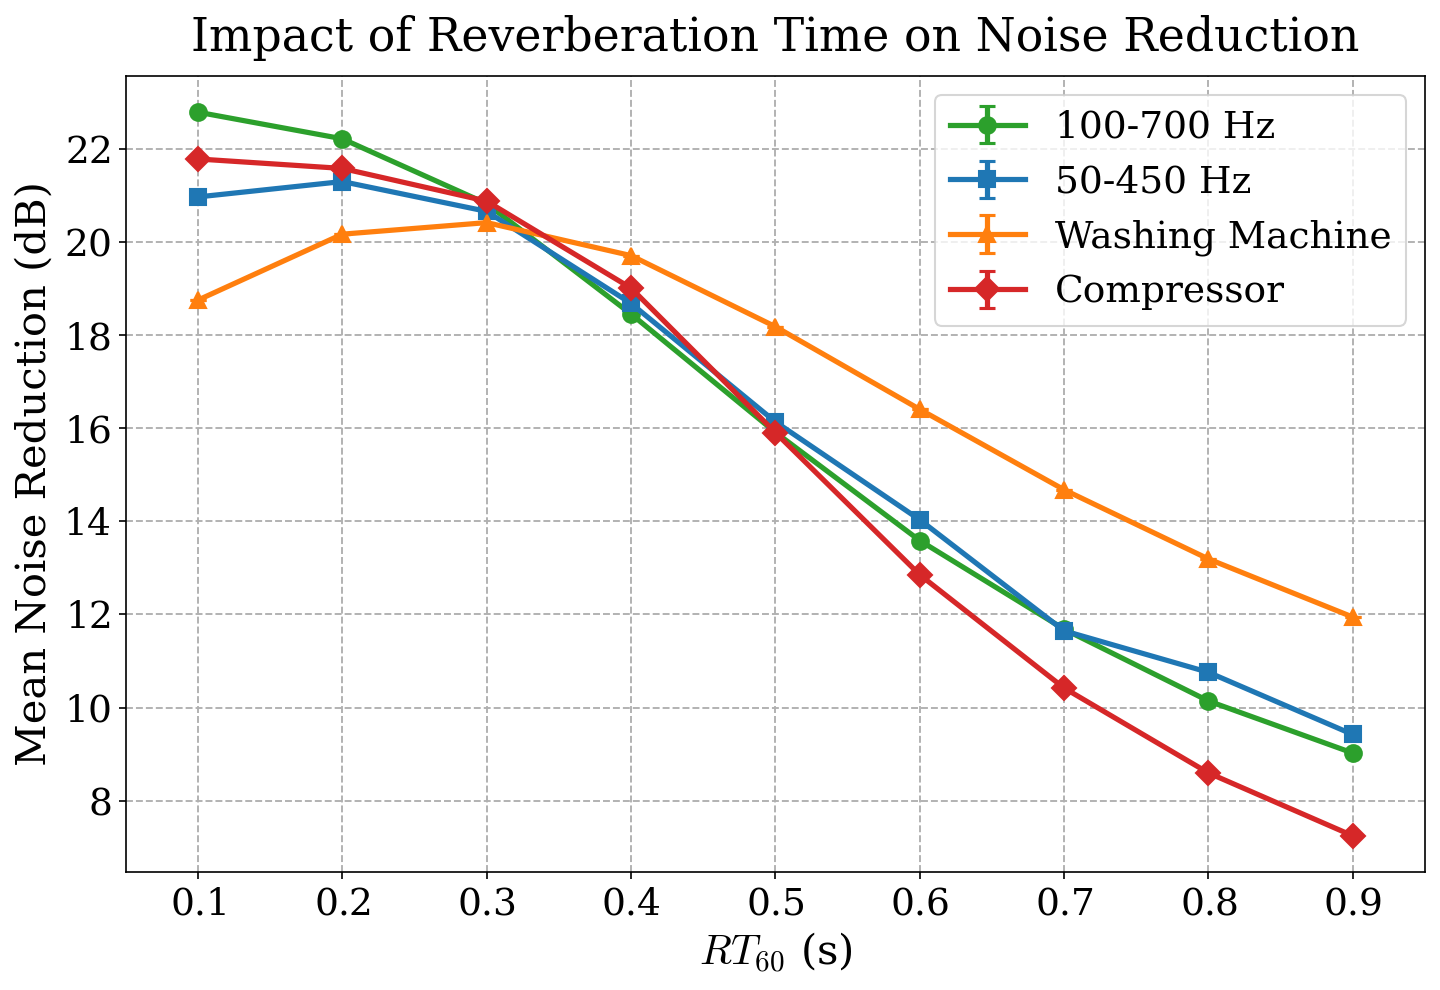

Saved figure to: outputs/fig10_nr_vs_rt60.png


In [5]:
plt.style.use('default')
plt.rcParams.update({
    'text.usetex': False,
    'mathtext.fontset': 'cm',
    'axes.formatter.use_mathtext': True,
    'font.family': 'serif',
    'font.size': 20,
    'axes.labelsize': 20,
    'axes.titlesize': 22,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 18,
    'axes.grid': True,
    'grid.alpha': 1,
    'grid.linestyle': '--',
    'grid.linewidth': 0.9,
})

colors = {
    '100-700 Hz': '#2ca02c',
    '50-450 Hz': '#1f77b4',
    'Washing Machine': '#ff7f0e',
    'Compressor': '#d62728',
}
markers = {
    '100-700 Hz': 'o',
    '50-450 Hz': 's',
    'Washing Machine': '^',
    'Compressor': 'D',
}

fig, ax = plt.subplots(figsize=(10, 7), dpi=150)

for noise_name in noise_configs:
    means = np.array(nr_mean[noise_name])
    stds = np.array(nr_std[noise_name])
    ax.errorbar(
        T60_VALUES,
        means,
        yerr=stds,
        marker=markers[noise_name],
        color=colors[noise_name],
        linewidth=2.5,
        markersize=8,
        capsize=4,
        capthick=1.5,
        label=noise_name,
    )

ax.set_title('Impact of Reverberation Time on Noise Reduction', pad=12)
ax.set_xlabel(r'$RT_{60}$ (s)')
ax.set_ylabel('Mean Noise Reduction (dB)')
ax.set_xlim(0.05, 0.95)
ax.set_xticks(T60_VALUES)
ax.legend(loc='upper right')
ax.grid(True, linestyle='--')
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

plt.tight_layout()
fig_path = OUTPUT_DIR / 'fig10_nr_vs_rt60.png'
fig.savefig(fig_path, dpi=600, bbox_inches='tight', pad_inches=0.1)
plt.show()

print(f'Saved figure to: {fig_path.relative_to(PROJECT_ROOT)}')